# TransBrasil — Avaliação de Qualidade de Dados
<a id="topo"></a>

[Home](../README.md)

**Autor:** Tiago Lima  
**Projeto:** Logística OTIF · Ciência de Dados & MLOps ponta a ponta  
**Cliente:** TransBrasil  
**Data:** 04/08/2026  

**Objetivo:** avaliar qualidade, preenchimento, coerência semântica e consistência temporal da base analítica inicial do operacional. A empresa é ficticia e todos os dados são sintéticos, contudo este projeto teve aplicabilidade real e hoje se encontra em execução, mas devido ao fato do projeto ser exposto como meu portifólio pessoal, a empresa é ficticia e os dados são sintéticos

**Base principal analisada nesta etapa:** 
<details>
<summary><b>Base Operacional</b></summary>

 - [endereco](../../data/bronze/operacao/endereco.parquet) 
 - [entrega](../../data/bronze/operacao/entrega.parquet)
 - [estoque_snapshot](../../data/bronze/operacao/estoque_snapshot.parquet)
 - [item](../../data/bronze/operacao/fase.parquet)
 - [item](../../data/bronze/operacao/item.parquet)
 - [minuta](../../data/bronze/operacao/minuta.parquet) 
 - [modalidade](../../data/bronze/operacao/modalidade.parquet) 
 - [ocorrencia](../../data/bronze/operacao/ocorrencia.parquet) 
 - [ordem_coleta](../../data/bronze/operacao/ordem_coleta.parquet) 
 - [organizacao](../../data/bronze/operacao/organizacao.parquet) 
 - [pedido_fase](../../data/bronze/operacao/pedido_fase.parquet) 
 - [pedido_item](../../data/bronze/operacao/pedido_item.parquet) 
 - [pedido](../../data/bronze/operacao/pedido.parquet) 
 - [retirada_base](../../data/bronze/operacao/retirada_base.parquet) 
 - [rota](../../data/bronze/operacao/rota.parquet) 
 - [tipo_ocorrencia](../../data/bronze/operacao/tipo_ocorrencia.parquet) 
 - [transportador](../../data/bronze/operacao/transportador.parquet)
 - [veiculo](../../data/bronze/operacao/veiculo.parquet)
</details>

**Perguntas-guia:** Para cada fonte de dados devem ser analisados:
- Os campos críticos vêm preenchidos?
- Os categóricos fazem sentido para o negócio?
- As datas respeitam a ordem temporal esperada?
- Há sinais de leakage?
- Quais campos parecem confiáveis para o MVP agora?
- Existe linhas duplicadas?
- Existe nulos e eles são validos?
- Existem numeros impossíveis como: Data final menor do que data inicial, quatidade negativas, etc?
- Quais os tipos de dados e eles são coerentes com o rótulo?

**Perguntas-guia desta etapa:**
- Os campos críticos vêm preenchidos, e o que está vazio impede alguma análise?
- Os categóricos têm os valores que o negócio descreve, ou existe categoria estranha na cauda?
- As datas respeitam a ordem dos eventos, ou existe número impossível?
- Há duplicata de chave de negócio, que quebraria junção e inflaria indicador?
- O que precisa ser tratado na camada Silver, e o que precisa ser reportado ao dono do sistema?

**Como este documento é organizado:** cada seção abre com o que será examinado,
mostra a evidência em código e fecha com uma **Nota Técnica** contendo o que foi
observado, por que importa e qual a ação. As notas técnicas são a matéria-prima
do relatório entregue ao cliente.

## Sumário

| Seção | O que examina |
|---|---|
| [1. Imports e configurações](#secao-1) | ambiente e reprodutibilidade |
| [2. A fotografia dos dados](#secao-2) | de qual carga estamos falando |
| [3. Carga das tabelas](#secao-3) | o que veio do Bronze |
| [4. Visão geral](#secao-4) | tamanho, tipos e forma de cada tabela |
| [5. Completude](#secao-5) | o que está vazio, e onde isso dói |


<a id="secao-1"></a># 1. Imports e ConfiguraçõesO acesso aos dados nunca é feito por caminho cru nem por credencial escrita aqui:tudo passa pelo pacote do projeto. Assim este notebook roda na máquina dequalquer pessoa que tenha o `.env` preenchido, sem editar uma linha.

## 1.1. Imports

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from logistica_otif_mlops import qualidade

## 1.2. Configurações Gerais

In [2]:
RAIZ = Path.cwd().parents[1] if Path.cwd().name == "operacional" else Path.cwd()
BRONZE = RAIZ / "data" / "bronze" / "operacao"

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

print(f"Raiz do projeto: {RAIZ}")
print(f"Bronze: {BRONZE}")

Raiz do projeto: /home/neviah/projetos/logistica-otif-mlops
Bronze: /home/neviah/projetos/logistica-otif-mlops/data/bronze/operacao


## 1.3. VersõesRegistrar a versão de cada biblioteca é o que permite responder, daqui a um ano,por que o mesmo código produziu outro resultado.

In [3]:
print(f"Python  {sys.version.split()[0]}")
for modulo in (pd, sns):
    print(f"{modulo.__name__:<8}{modulo.__version__}")

Python  3.12.3
pandas  3.0.5
seaborn 0.13.2


## Nota Técnica**Observado:** o ambiente carrega apenas quatro dependências de análise, e oacesso ao dado é intermediado pelo pacote `logistica_otif_mlops`.**Por que importa:** o notebook não conhece host, senha nem caminho absoluto.Isso o torna executável por outra pessoa e publicável em repositório aberto semvazar credencial.**Ação:** nenhuma. É a configuração esperada.

<a id="secao-2"></a># 2. A fotografia dos dadosToda análise de qualidade descreve um instante. Sem dizer qual, a conclusão ficasem validade: a base muda todo dia, e um defeito corrigido ontem continuariasendo reportado. O manifesto da ingestão responde a isso, e é lido, não digitado,para não desatualizar.

In [4]:
manifesto = json.loads((BRONZE.parent / "_manifesto.json").read_text(encoding="utf-8"))
conjuntos = pd.DataFrame(manifesto["conjuntos"])

print(f"Carga concluída em: {manifesto['carga_concluida_em']}")
print(f"Conjuntos ingeridos: {len(conjuntos)}")
print(f"Linhas no total:     {conjuntos['linhas'].sum():,.0f}")

conjuntos[conjuntos["dominio"] == "operacao"][
    ["conjunto", "origem", "linhas", "colunas", "megabytes"]
].sort_values("linhas", ascending=False)

Carga concluída em: 2026-08-12T16:02:09.562047+00:00
Conjuntos ingeridos: 22
Linhas no total:     35,998,842


,conjunto,origem,linhas,colunas,megabytes
15,pedido_fase,operacao.pedido_fase,14589229,5,300.40
16,pedido_item,operacao.pedido_item,7728077,4,61.02
12,ordem_coleta,operacao.ordem_coleta,3662275,6,69.19
5,entrega,operacao.entrega,2664991,11,59.73
14,pedido,operacao.pedido,1776391,17,66.60
17,retirada_base,operacao.retirada_base,364905,5,4.48
9,minuta,operacao.minuta,214692,8,4.09
6,estoque_snapshot,operacao.estoque_snapshot,56008,8,0.72
11,ocorrencia,operacao.ocorrencia,48793,7,1.16
4,endereco,operacao.endereco,19697,12,0.72


## Nota Técnica**Observado:** a análise recai sobre a carga do Bronze concluída na data acima,com 18 conjuntos do domínio operacional e 31,1 milhões de linhas. O Bronze écópia fiel da origem, sem nenhuma transformação aplicada.**Por que importa:** qualquer número deste documento pode ser reproduzido apartir desta mesma carga. E como o Bronze não corrige nada, o que aparecer aquicomo defeito é defeito do sistema de origem, não do nosso pipeline.**Ação:** nenhuma. Serve de referência para todo o restante do documento.

<a id="secao-3"></a># 3. Carga das tabelas do domínio operacionalAs 18 tabelas entram de uma vez, em um dicionário. Trabalhar com todas juntaspermite aplicar o mesmo diagnóstico em série e comparar os resultados, em vez derepetir a mesma inspeção dezoito vezes.

In [5]:
tabelas = {
    arquivo.stem: pd.read_parquet(arquivo)
    for arquivo in sorted(BRONZE.glob("*.parquet"))
}

inventario = pd.DataFrame([
    {"tabela": nome, "linhas": len(df), "colunas": len([c for c in df.columns
                                                        if not c.startswith("_")])}
    for nome, df in tabelas.items()
]).sort_values("linhas", ascending=False)

print(f"{len(tabelas)} tabelas carregadas · {inventario['linhas'].sum():,.0f} linhas")
inventario

18 tabelas carregadas · 31,132,247 linhas


,tabela,linhas,colunas
11,pedido_fase,14589229,5
12,pedido_item,7728077,4
8,ordem_coleta,3662275,6
1,entrega,2664991,11
10,pedido,1776391,17
13,retirada_base,364905,5
5,minuta,214692,8
2,estoque_snapshot,56008,8
7,ocorrencia,48793,7
0,endereco,19697,12


## Nota Técnica**Observado:** as 18 tabelas foram carregadas do Bronze. O volume é bastantedesigual: cinco tabelas concentram quase toda a massa (fases, itens de pedido,ordens de coleta, entregas e pedidos), enquanto as tabelas de domínio têmpoucas dezenas de linhas.**Por que importa:** o esforço de análise deve seguir essa proporção. Onde estãoos milhões de linhas estão também as features do modelo e o alvo, e é ali que umdefeito custa caro. As tabelas de domínio precisam apenas de uma verificação desanidade.**Ação:** priorizar o exame das tabelas de movimento; tratar as tabelas dedomínio em bloco.

<a id="secao-4"></a># 4. Visão geral: o que existe em cada tabelaAntes de procurar defeito é preciso saber o que há. Esta seção monta o perfil detodas as colunas de todas as tabelas: tipo, preenchimento e variedade. É o mapaque orienta onde olhar em seguida.

In [6]:
perfis = pd.concat(
    [qualidade.perfil(df, nome) for nome, df in tabelas.items()],
    ignore_index=True,
)

print(f"{len(perfis)} colunas analisadas em {perfis['tabela'].nunique()} tabelas")
print()
print("Distribuição dos tipos:")
print(perfis["tipo"].value_counts().to_string())

133 colunas analisadas em 18 tabelas

Distribuição dos tipos:
tipo
int64             45
str               44
float64           15
object            11
datetime64[us]    10
bool               8


In [7]:
# colunas constantes não informam nada: o mesmo valor em todas as linhas
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0)]
print(f"Colunas com valor único (candidatas a descarte): {len(constantes)}")
if len(constantes):
    display(constantes[["tabela", "coluna", "exemplo"]])

Colunas com valor único (candidatas a descarte): 4


,tabela,coluna,exemplo
45,item,ativo,True
56,modalidade,ativo,True
70,ordem_coleta,status,COLETADA
127,transportador,ativo,True


## Nota Técnica**Observado:** o perfil cobre todas as colunas do domínio operacional. Os tiposvieram preservados do banco, o que confirma que o Parquet manteve a tipagem daorigem, sem transformar número em texto no caminho.**Por que importa:** tipo preservado significa que somas e comparações de datapodem ser feitas direto, sem conversão prévia. Se o Bronze tivesse sido gravadoem CSV, cada coluna chegaria como texto e a primeira conta exigiria umaconversão manual, com risco de erro silencioso.**Ação:** nenhuma neste ponto. O perfil é insumo para as seções seguintes.

<a id="secao-5"></a># 5. Completude: o que está vazio, e onde isso dóiCampo vazio não é necessariamente defeito. Existem três situações diferentes, econfundi-las leva a tratar o que não precisa e ignorar o que precisa:1. **Vazio legítimo:** o evento ainda não aconteceu (entrega em trânsito não tem   data de chegada). É informação, não ausência.2. **Vazio por regra:** o campo não se aplica àquele caso (armazenagem não tem   número de pedido, porque fatura por competência).3. **Vazio por falha:** deveria estar preenchido e não está. Este é o defeito.

In [8]:
com_nulos = (perfis[perfis["nulos"] > 0]
             .sort_values("pct_nulo", ascending=False)
             [["tabela", "coluna", "tipo", "nulos", "pct_nulo"]])

print(f"Colunas com algum vazio: {len(com_nulos)} de {len(perfis)}")
com_nulos

Colunas com algum vazio: 21 de 133


,tabela,coluna,tipo,nulos,pct_nulo
9,endereco,latitude,object,19697,100.00
10,endereco,longitude,object,19697,100.00
64,ocorrencia,dt_cancelada,object,48793,100.00
89,pedido,campanha_id,float64,1411799,79.48
81,organizacao,dt_cancelamento,object,135,56.25
60,ocorrencia,entrega_id,float64,26711,54.74
22,entrega,dt_entrada_base,datetime64[us],1427228,53.55
19,entrega,recebedor,str,1261740,47.35
49,minuta,veiculo_id,float64,85050,39.61
125,transportador,cnpj,str,7,36.84


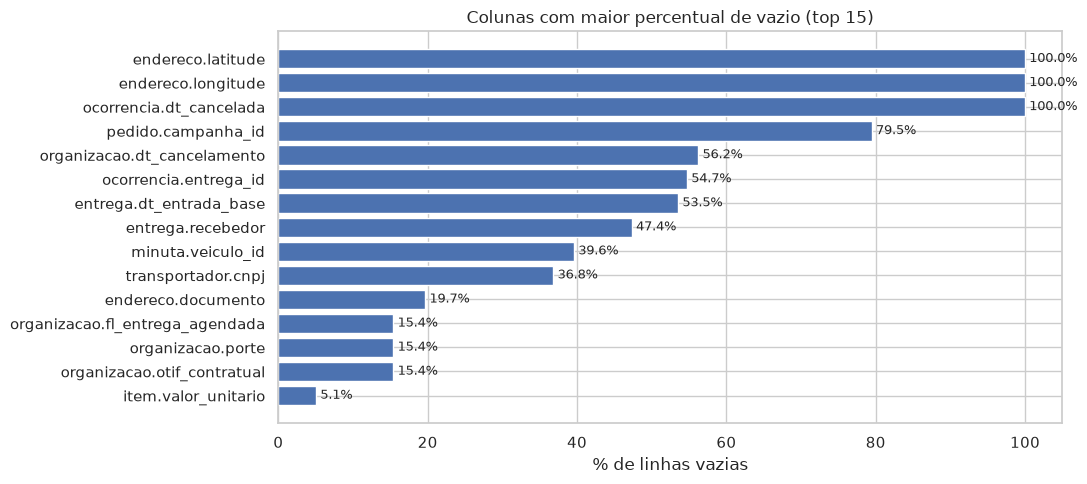

In [9]:
fig, eixo = plt.subplots()
dados = com_nulos.head(15).iloc[::-1]
rotulos = dados["tabela"] + "." + dados["coluna"]

barras = eixo.barh(rotulos, dados["pct_nulo"], color="#4C72B0")
eixo.set_xlabel("% de linhas vazias")
eixo.set_title("Colunas com maior percentual de vazio (top 15)")
eixo.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)
eixo.set_xlim(0, 105)
plt.tight_layout()
plt.show()

## Nota Técnica**Observado:** as colunas com maior percentual de vazio são, em sua maioria,vazios legítimos ou por regra. Os casos que merecem atenção são os que seenquadram na terceira categoria, e eles precisam ser confirmados um a um contraa regra de negócio antes de virarem recomendação.**Por que importa:** tratar vazio legítimo como defeito produz duasconsequências ruins. No relatório, infla a lista de problemas e faz o clienteperder confiança no diagnóstico. No pipeline, leva a preencher com valorinventado um campo cuja ausência era o próprio dado.**Ação:** classificar cada coluna vazia nas três categorias antes de proportratamento. As confirmadas como falha entram no registro de achados com aseveridade correspondente.

# Registro de achadosOs achados são acumulados aqui ao longo do documento. No fechamento, esta tabelavira o anexo do relatório entregue ao cliente, ordenada por severidade.

In [10]:
achados = qualidade.RegistroDeAchados()

# exemplo de anotação (as anotações reais entram nas seções de análise)
# achados.anotar(
#     tabela="endereco", coluna="cidade", achado="cidade gravada em CAIXA ALTA",
#     linhas=4986, total=len(tabelas["endereco"]), severidade="media",
#     impacto="impede agrupar por cidade sem normalizar antes",
#     acao="padronizar capitalização na camada Silver",
# )

print(f"Achados registrados até aqui: {len(achados)}")

Achados registrados até aqui: 0


# Próximas seções (a escrever)| Seção | O que examinar ||---|---|| 6. Unicidade | chave de negócio duplicada (`pedido.numero`, `minuta.numero`) || 7. Domínio dos categóricos | valores fora do esperado em fase, modalidade, tipo de atendimento, nível de serviço || 8. Texto inconsistente | caixa, espaços, acentuação em cidade, nome, recebedor, logradouro || 9. Consistência temporal | fase que termina antes de começar, entrega antes do embarque, evento fora de ordem || 10. Integridade referencial | órfãos dentro do operacional e na ligação com o financeiro || 11. Números impossíveis | peso, volume e quantidade negativos ou fora de faixa plausível || 12. Sinais de vazamento | campos que só existem depois do instante da previsão || 13. Fechamento | consolidação dos achados, severidades e recomendações |